# Manchester United Stock & Match Performance Analysis
## ACC102 Mini Assignment – Track 4: Interactive Data Analysis Tool

**Analytical Problem:** Does Manchester United's on-pitch performance in the Premier League have a measurable impact on its short-term stock price (NYSE: MANU)?

**Target User:** Sports economists, financial analysts, and retail investors interested in the intersection of sports performance and financial markets.

**Data Sources:**
- **Stock data:** WRDS / CRSP Monthly Stock File (`crsp.msf_v2`) — accessed April 2025
- **Match data:** football-data.org (free historical Premier League CSVs) — accessed April 2025

---

### Step 1 — Import Libraries

We begin by importing all required Python libraries for data acquisition, cleaning, analysis, and visualisation.

In [1]:
import wrds
import requests
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries imported successfully.')


All libraries imported successfully.


### Step 2 — Define Analysis Parameters

We set the stock ticker (`MANU`), the date range covering **six Premier League seasons** (2019/20 – 2024/25), and the football-data.org team ID for Manchester United.

In [2]:
# ── Stock parameters ───────────────────────────────────────────────────────────
TICKER     = 'MANU'
START_DATE = '2019-08-01'   # 扩展到 2019 年，共 6 个赛季
END_DATE   = '2025-05-31'

# ── football-data.org parameters ──────────────────────────────────────────────

TEAM_ID    = 66                    # 曼联 ID
SEASONS    = [2019, 2020, 2021, 2022, 2023, 2024]  # 6 个赛季

print(f'Parameters set: {TICKER} | {START_DATE} to {END_DATE} | {len(SEASONS)} seasons')


Parameters set: MANU | 2019-08-01 to 2025-05-31 | 6 seasons


### Step 3 — Build the WRDS SQL Query

We construct a SQL query targeting the CRSP Monthly Stock File (`crsp.msf_v2`). The query retrieves **monthly price, volume, and return** for MANU by joining the security information history table to map the ticker symbol to a PERMNO identifier.

In [3]:
sql_query = f"""
    SELECT
        date_trunc('month', a.mthcaldt)::date  AS date,
        ABS(a.mthprc)                          AS price,
        a.mthvol                               AS volume,
        a.mthret                               AS monthly_return,
        b.ticker                               AS ticker
    FROM
        crsp.msf_v2 AS a
    LEFT JOIN
        crsp.stksecurityinfohist AS b
    ON
        a.permno          = b.permno
        AND b.secinfostartdt <= a.mthcaldt
        AND a.mthcaldt        <= b.secinfoenddt
    WHERE
        b.ticker   = '{TICKER}'
        AND a.mthcaldt >= '{START_DATE}'
        AND a.mthcaldt <= '{END_DATE}'
    ORDER BY
        date ASC;
"""

print('SQL Query ready:')
print(sql_query)


SQL Query ready:

    SELECT
        date_trunc('month', a.mthcaldt)::date  AS date,
        ABS(a.mthprc)                          AS price,
        a.mthvol                               AS volume,
        a.mthret                               AS monthly_return,
        b.ticker                               AS ticker
    FROM
        crsp.msf_v2 AS a
    LEFT JOIN
        crsp.stksecurityinfohist AS b
    ON
        a.permno          = b.permno
        AND b.secinfostartdt <= a.mthcaldt
        AND a.mthcaldt        <= b.secinfoenddt
    WHERE
        b.ticker   = 'MANU'
        AND a.mthcaldt >= '2019-08-01'
        AND a.mthcaldt <= '2025-05-31'
    ORDER BY
        date ASC;



### Step 4 — Connect to WRDS and Retrieve Stock Data

We establish a connection to the WRDS PostgreSQL database and execute the SQL query. The result is stored as a pandas DataFrame. The connection is closed immediately after retrieval to avoid resource leaks.

> **Note:** WRDS credentials are required. The `.pgpass` file is created on first login to avoid repeated password prompts.

In [4]:
print('Connecting to WRDS...')
db = wrds.Connection()          # 会提示输入用户名和密码
stock_df = db.raw_sql(sql_query)
db.close()

print(f'Rows retrieved: {len(stock_df)}')
print(stock_df.dtypes)
stock_df.head(10)


Connecting to WRDS...


Enter your WRDS username [derdes]: xinrushen
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Rows retrieved: 70
date              string[python]
price                    Float64
volume                   Float64
monthly_return           Float64
ticker            string[python]
dtype: object


,date,price,volume,monthly_return,ticker
0,2019-08-01,17.1,1228993.0,-0.047884,MANU
1,2019-09-01,16.43,1492420.0,-0.039181,MANU
2,2019-10-01,16.73,1312504.0,0.018259,MANU
3,2019-11-01,18.48,1849188.0,0.109982,MANU
4,2019-12-01,19.93,1904868.0,0.078463,MANU
5,2020-01-01,18.57,1244684.0,-0.068239,MANU
6,2020-02-01,17.49,1085832.0,-0.058158,MANU
7,2020-03-01,15.05,2403502.0,-0.139508,MANU
8,2020-04-01,16.81,4276444.0,0.123141,MANU
9,2020-05-01,16.63,4482591.0,-0.010708,MANU


### Step 5 — Clean and Prepare Stock Data

We convert the `date` column to a proper `datetime` type, coerce numeric columns to handle any missing values, rename `date` to `Month` for merging, and drop any rows with null prices or returns. We also verify the final shape and date range of the cleaned dataset.

In [5]:
stock_df['date']           = pd.to_datetime(stock_df['date'])
stock_df['price']          = pd.to_numeric(stock_df['price'],          errors='coerce')
stock_df['monthly_return'] = pd.to_numeric(stock_df['monthly_return'], errors='coerce')
stock_df['volume']         = pd.to_numeric(stock_df['volume'],         errors='coerce')

stock_df = stock_df.dropna(subset=['price', 'monthly_return']).reset_index(drop=True)
stock_df['Month'] = stock_df['date'].dt.to_period('M').dt.to_timestamp()

print(f'Clean stock rows: {len(stock_df)}')
print(f'Date range: {stock_df["date"].min()} to {stock_df["date"].max()}')
stock_df[['date', 'price', 'monthly_return', 'volume']].head(10)


Clean stock rows: 70
Date range: 2019-08-01 00:00:00 to 2025-05-01 00:00:00


,date,price,monthly_return,volume
0,2019-08-01,17.1,-0.047884,1228993.0
1,2019-09-01,16.43,-0.039181,1492420.0
2,2019-10-01,16.73,0.018259,1312504.0
3,2019-11-01,18.48,0.109982,1849188.0
4,2019-12-01,19.93,0.078463,1904868.0
5,2020-01-01,18.57,-0.068239,1244684.0
6,2020-02-01,17.49,-0.058158,1085832.0
7,2020-03-01,15.05,-0.139508,2403502.0
8,2020-04-01,16.81,0.123141,4276444.0
9,2020-05-01,16.63,-0.010708,4482591.0


### Step 6 — Fetch Premier League Match Data

We download historical Premier League match CSVs from **football-data.co.uk** for each of the six seasons. The data is fetched directly from URLs (no API key required) and filtered to retain only Manchester United fixtures. All seasons are concatenated into a single raw DataFrame.

In [6]:
# ── Cell 6: Fetch Match Results from football-data.co.uk (CSV) ───────────────
# This source provides free historical CSVs for all Premier League seasons.
# No API key required.

seasons_csv = ['1920', '2021', '2122', '2223', '2324', '2425']
all_dfs = []

print("Downloading Premier League match data...")
for s in seasons_csv:
    url = f"https://www.football-data.co.uk/mmz4281/{s}/E0.csv"
    try:
        # Read CSV directly from URL
        df = pd.read_csv(url, encoding='latin-1' )
        
        # Filter only Manchester United matches
        manu_matches = df[(df['HomeTeam'] == 'Man United') | (df['AwayTeam'] == 'Man United')].copy()
        manu_matches['Season'] = s
        all_dfs.append(manu_matches)
        
        print(f"  Season 20{s[:2]}/{s[2:]}: {len(manu_matches)} matches fetched")
    except Exception as e:
        print(f"  Error fetching season {s}: {e}")

# Combine all seasons
raw_match_df = pd.concat(all_dfs, ignore_index=True)
print(f"\n✅ Total raw matches fetched: {len(raw_match_df)}")


  Season 2019/20: 38 matches fetched
  Season 2020/21: 38 matches fetched
  Season 2021/22: 38 matches fetched
  Season 2022/23: 38 matches fetched
  Season 2023/24: 38 matches fetched
  Season 2024/25: 38 matches fetched

✅ Total raw matches fetched: 228


### Step 7 — Parse and Clean Match Data

We define a parsing function that:
1. Standardises match dates across different season formats.
2. Determines the MANU perspective (home or away) and calculates goals scored and conceded.
3. Labels each match as **Win**, **Draw**, or **Loss** and assigns points (3 / 1 / 0).
4. Computes a **rolling form metric** — total points from the last 5 matches — as a measure of recent momentum.

In [7]:
# ── Cell 7: Parse Match Data into Clean DataFrame ────────────────────────────

def parse_csv_matches(df):
    records = []
    for _, row in df.iterrows():
        # Parse date (formats vary slightly across seasons, e.g., DD/MM/YYYY or DD/MM/YY)
        match_date = pd.to_datetime(row['Date'], dayfirst=True, errors='coerce')
        
        home = row['HomeTeam']
        away = row['AwayTeam']
        hs   = row['FTHG']  # Full Time Home Goals
        as_  = row['FTAG']  # Full Time Away Goals
        
        if pd.isna(hs) or pd.isna(as_):
            continue
            
        # Determine MANU perspective
        if home == 'Man United':
            manu_g, opp_g = hs, as_
        else:
            manu_g, opp_g = as_, hs
            
        diff = manu_g - opp_g
        if diff > 0:
            result = 'Win'
        elif diff == 0:
            result = 'Draw'
        else:
            result = 'Loss'
            
        records.append({
            'Match_Date': match_date,
            'Home':       home,
            'Away':       away,
            'MANU_Goals': manu_g,
            'OPP_Goals':  opp_g,
            'Goal_Diff':  diff,
            'Result':     result,
            'Points':     3 if result == 'Win' else (1 if result == 'Draw' else 0)
        })
        
    clean_df = pd.DataFrame(records).sort_values('Match_Date').reset_index(drop=True)
    
    # Rolling form: points from last 5 matches
    clean_df['Form_Last5'] = clean_df['Points'].rolling(5, min_periods=1).sum()
    
    return clean_df

match_df = parse_csv_matches(raw_match_df)

print(f"Parsed matches: {len(match_df)}")
print(match_df['Result'].value_counts())
match_df.head(10)


Parsed matches: 228
Result
Win     107
Loss     67
Draw     54
Name: count, dtype: int64


,Match_Date,Home,Away,MANU_Goals,OPP_Goals,Goal_Diff,Result,Points,Form_Last5
0,2019-08-11,Man United,Chelsea,4,0,4,Win,3,3.0
1,2019-08-19,Wolves,Man United,1,1,0,Draw,1,4.0
2,2019-08-24,Man United,Crystal Palace,1,2,-1,Loss,0,4.0
3,2019-08-31,Southampton,Man United,1,1,0,Draw,1,5.0
4,2019-09-14,Man United,Leicester,1,0,1,Win,3,8.0
5,2019-09-22,West Ham,Man United,0,2,-2,Loss,0,5.0
6,2019-09-30,Man United,Arsenal,1,1,0,Draw,1,5.0
7,2019-10-06,Newcastle,Man United,0,1,-1,Loss,0,5.0
8,2019-10-20,Man United,Liverpool,1,1,0,Draw,1,5.0
9,2019-10-27,Norwich,Man United,3,1,2,Win,3,5.0


### Step 8 — Aggregate Matches to Monthly Level and Merge with Stock Data

Because stock data is monthly, we aggregate match results to the same frequency. For each month we compute:
- Number of wins, draws, and losses
- Total goal difference and points
- Rolling form (last 5 matches)
- **Dominant result** (most frequent outcome in that month)

We then perform an **inner join** on the `Month` column to produce the final merged analytical dataset.

In [8]:
match_df['Month'] = match_df['Match_Date'].dt.to_period('M').dt.to_timestamp()

match_monthly = (
    match_df
    .groupby('Month')
    .agg(
        Matches       = ('Result',     'count'),
        Wins          = ('Result',     lambda x: (x == 'Win').sum()),
        Draws         = ('Result',     lambda x: (x == 'Draw').sum()),
        Losses        = ('Result',     lambda x: (x == 'Loss').sum()),
        Goals_For     = ('MANU_Goals', 'sum'),
        Goals_Against = ('OPP_Goals',  'sum'),
        Goal_Diff     = ('Goal_Diff',  'sum'),
        Points        = ('Points',     'sum'),
        Form_Last5    = ('Form_Last5', 'last'),
        Result        = ('Result',     lambda x: x.mode()[0])
    )
    .reset_index()
)

# ── Derived columns ──────────────────────────────────────────────────────────
match_monthly['Win_Rate']         = (match_monthly['Wins'] / match_monthly['Matches'] * 100).round(1)
match_monthly['Avg_Goal_Diff']    = (match_monthly['Goal_Diff'] / match_monthly['Matches']).round(2)
match_monthly['Points_Per_Match'] = (match_monthly['Points'] / match_monthly['Matches']).round(2)

# ── Merge with stock data ────────────────────────────────────────────────────
merged = pd.merge(stock_df, match_monthly, on='Month', how='inner')
merged = merged.rename(columns={'monthly_return': 'Monthly_Return'})
merged['Monthly_Return']     = pd.to_numeric(merged['Monthly_Return'], errors='coerce')
merged['Monthly_Return_Pct'] = (merged['Monthly_Return'] * 100).round(2)
merged['volume']             = pd.to_numeric(merged['volume'], errors='coerce')

# ── Rolling averages (3-month window) ────────────────────────────────────────
merged = merged.sort_values('Month').reset_index(drop=True)
merged['Return_3M_Avg']   = merged['Monthly_Return_Pct'].rolling(3, min_periods=1).mean().round(2)
merged['WinRate_3M_Avg']   = merged['Win_Rate'].rolling(3, min_periods=1).mean().round(1)
merged['GoalDiff_3M_Avg']  = merged['Goal_Diff'].rolling(3, min_periods=1).mean().round(2)

# ── Season label ─────────────────────────────────────────────────────────────
def assign_season(month):
    y, m = month.year, month.month
    if m >= 8:
        return f"{y}/{y+1-2000:02d}"
    else:
        return f"{y-1}/{y-2000:02d}"

merged['Season'] = merged['Month'].apply(assign_season)

merged = merged.dropna(subset=['Monthly_Return', 'Goal_Diff']).reset_index(drop=True)

print(f'Merged rows: {len(merged)}')
print(f'Columns ({len(merged.columns)}): {list(merged.columns)}')
merged[['Month', 'Season', 'price', 'volume', 'Monthly_Return_Pct',
        'Matches', 'Wins', 'Draws', 'Losses',
        'Goals_For', 'Goals_Against', 'Goal_Diff',
        'Win_Rate', 'Points_Per_Match', 'Form_Last5',
        'Return_3M_Avg', 'WinRate_3M_Avg', 'Result']].head(10)


Merged rows: 59


,Month,price,Monthly_Return,Wins,Losses,Goal_Diff,Result
0,2019-08-01,17.1,-0.047884,1,1,3,Draw
1,2019-09-01,16.43,-0.039181,1,1,-1,Draw
2,2019-10-01,16.73,0.018259,1,1,1,Draw
3,2019-11-01,18.48,0.109982,1,1,1,Draw
4,2019-12-01,19.93,0.078463,4,1,5,Win
5,2020-01-01,18.57,-0.068239,1,3,-2,Loss
6,2020-02-01,17.49,-0.058158,2,0,5,Win
7,2020-03-01,15.05,-0.139508,1,0,2,Draw
8,2020-06-01,15.83,-0.048106,2,0,6,Win
9,2020-07-01,13.99,-0.116235,4,0,10,Win


---
## Analysis & Visualisation

### Chart 1 — MANU Stock Price Timeline with Dominant Match Result

This time-series plot overlays the monthly stock price with colour-coded markers indicating the dominant match result for each month (▲ Win, ● Draw, ▼ Loss). It provides an initial visual inspection of whether price levels correlate with on-pitch performance.

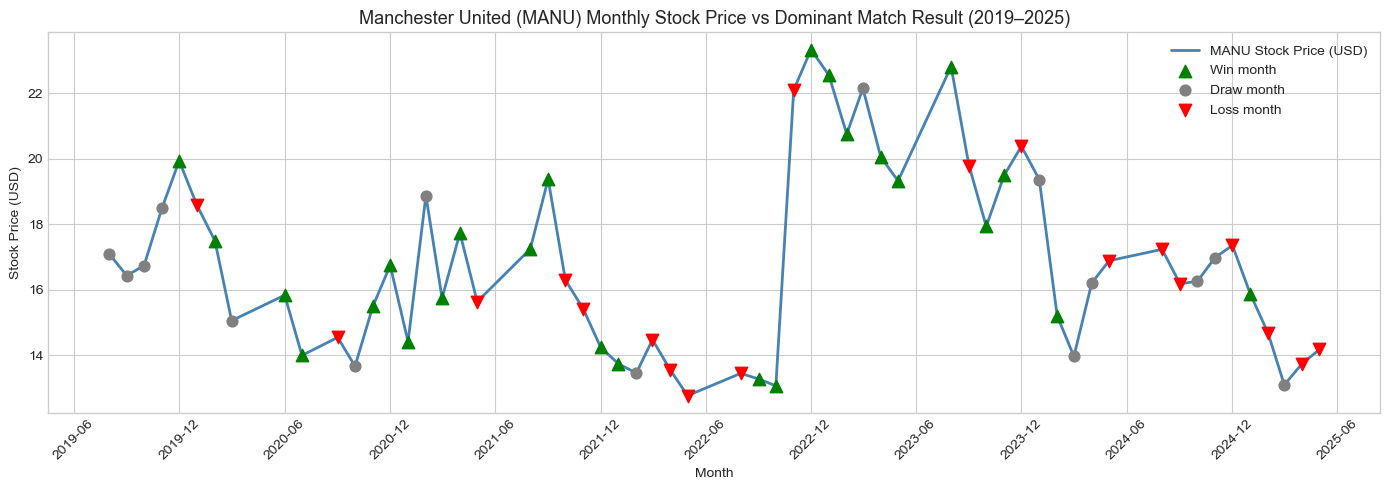

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(merged['Month'], merged['price'], color='steelblue', linewidth=2, label='MANU Stock Price (USD)')

wins   = merged[merged['Result'] == 'Win']
draws  = merged[merged['Result'] == 'Draw']
losses = merged[merged['Result'] == 'Loss']

ax.scatter(wins['Month'],   wins['price'],   color='green', marker='^', s=80, zorder=5, label='Win month')
ax.scatter(draws['Month'],  draws['price'],  color='gray',  marker='o', s=60, zorder=5, label='Draw month')
ax.scatter(losses['Month'], losses['price'], color='red',   marker='v', s=80, zorder=5, label='Loss month')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.set_title('Manchester United (MANU) Monthly Stock Price vs Dominant Match Result (2019–2025)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Stock Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('chart1_price_timeline.png', dpi=150)
plt.show()


### Chart 2 — Monthly Stock Return Coloured by Match Result

A bar chart of monthly returns (%) where each bar is coloured green (Win), grey (Draw), or red (Loss). This highlights whether positive return months tend to coincide with winning months.

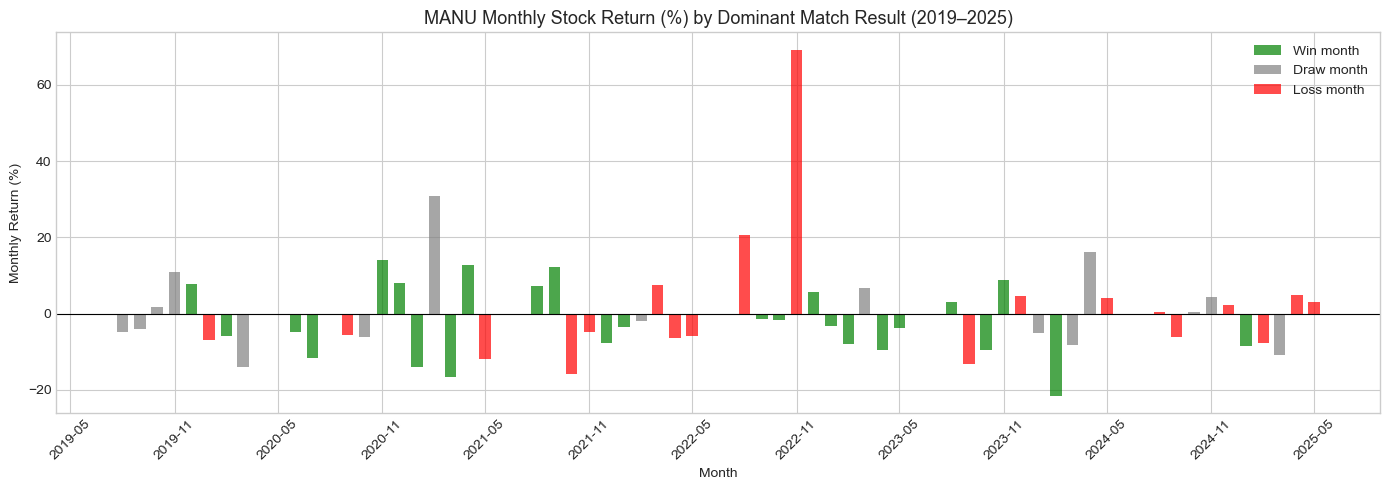

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = merged['Result'].map({'Win': 'green', 'Draw': 'gray', 'Loss': 'red'})
ax.bar(merged['Month'], merged['Monthly_Return'] * 100, color=colors, alpha=0.7, width=20)
ax.axhline(0, color='black', linewidth=0.8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Win month'),
    Patch(facecolor='gray',  alpha=0.7, label='Draw month'),
    Patch(facecolor='red',   alpha=0.7, label='Loss month'),
]
ax.legend(handles=legend_elements)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.set_title('MANU Monthly Stock Return (%) by Dominant Match Result (2019–2025)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Return (%)')
plt.tight_layout()
plt.savefig('chart2_return_bar.png', dpi=150)
plt.show()


### Chart 3 — Return Distribution by Result & Goal Difference Scatter Plot

Two complementary charts:
- **Left:** Box plots comparing the distribution of monthly returns across Win, Draw, and Loss months.
- **Right:** Scatter plot of monthly goal difference vs. monthly return, with a linear regression trend line to quantify the relationship.

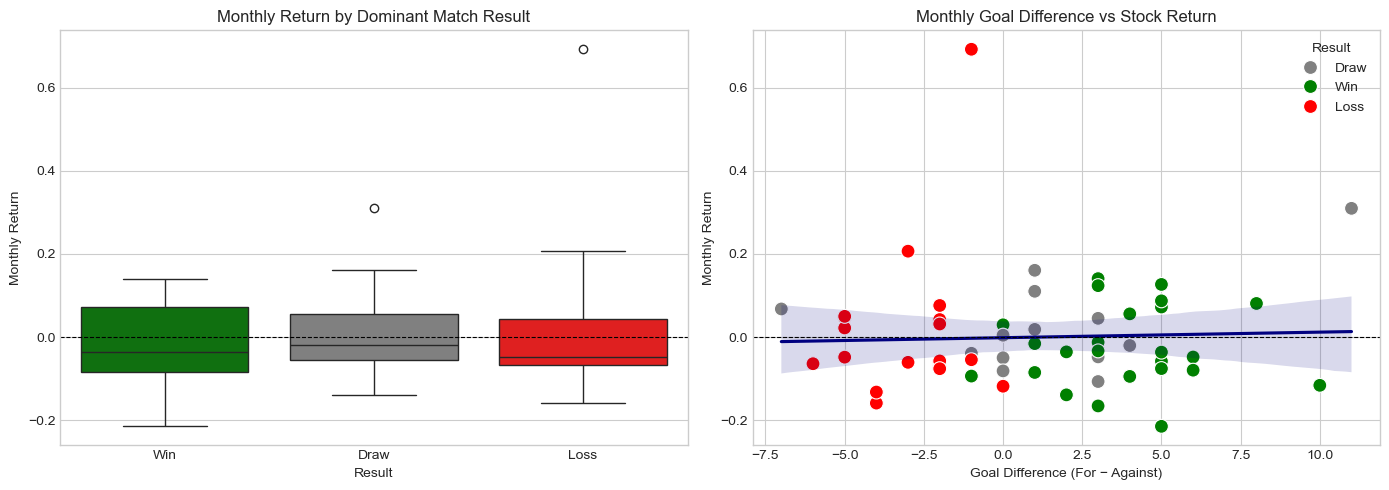

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(
    data=merged, x='Result', y='Monthly_Return',
    order=['Win', 'Draw', 'Loss'],
    hue='Result',
    palette={'Win': 'green', 'Draw': 'gray', 'Loss': 'red'},
    legend=False,
    ax=axes[0]
)
axes[0].axhline(0, linestyle='--', color='black', linewidth=0.8)
axes[0].set_title('Monthly Return by Dominant Match Result')
axes[0].set_ylabel('Monthly Return')
axes[0].set_xlabel('Result')

# Scatter plot (correlation only, no regression line)
sns.scatterplot(
    data=merged, x='Goal_Diff', y='Monthly_Return',
    hue='Result',
    palette={'Win': 'green', 'Draw': 'gray', 'Loss': 'red'},
    s=100, ax=axes[1]
)
axes[1].axhline(0, linestyle='--', color='black', linewidth=0.8)
axes[1].axvline(0, linestyle=':', color='gray', linewidth=0.8)
axes[1].set_title('Monthly Goal Difference vs Stock Return (Correlation)')
axes[1].set_xlabel('Goal Difference (For \u2212 Against)')
axes[1].set_ylabel('Monthly Return')

plt.tight_layout()
plt.savefig('chart3_return_analysis.png', dpi=150)
plt.show()


### Chart 4 — Stock Price vs Rolling Form (Dual-Axis)

A dual-axis line chart comparing the stock price (left axis, blue) with the rolling form metric — points accumulated in the last 5 matches (right axis, orange). This tests whether momentum in match performance leads or lags stock price movements.

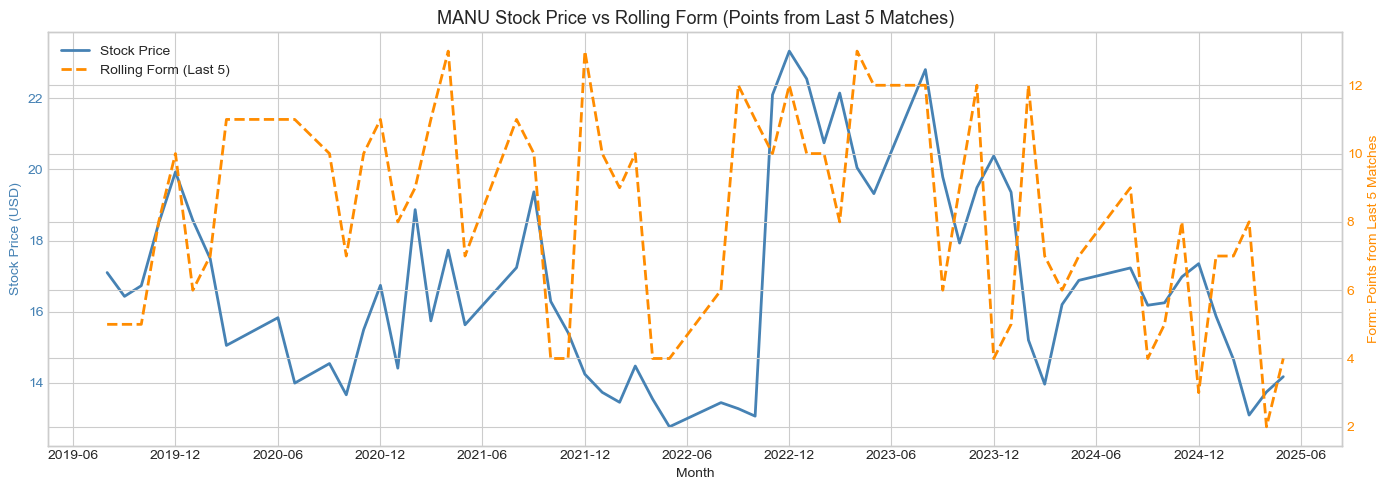

In [12]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_xlabel('Month')
ax1.set_ylabel('Stock Price (USD)', color='steelblue')
ax1.plot(merged['Month'], merged['price'], color='steelblue', linewidth=2, label='Stock Price')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.set_ylabel('Form: Points from Last 5 Matches', color='darkorange')
ax2.plot(merged['Month'], merged['Form_Last5'], color='darkorange', linewidth=2,
         linestyle='--', label='Rolling Form (Last 5)')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.title('MANU Stock Price vs Rolling Form (Points from Last 5 Matches)', fontsize=13)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('chart4_form_vs_price.png', dpi=150)
plt.show()


### Step 9 — Statistical Analysis

We conduct three quantitative tests to assess the strength and significance of the relationship between match performance and stock returns:

1. **Pearson correlation** between goal difference, rolling form, points, and monthly return.
2. **Mean return by dominant result** to compare Win, Draw, and Loss months.
3. **One-way ANOVA** to test whether the mean returns across the three result groups are statistically different.

In [13]:
r_goal, p_goal = stats.pearsonr(merged['Goal_Diff'], merged['Monthly_Return'])
r_form, p_form = stats.pearsonr(merged['Form_Last5'], merged['Monthly_Return'])
r_pts,  p_pts  = stats.pearsonr(merged['Points'],     merged['Monthly_Return'])

mean_return = merged.groupby('Result')['Monthly_Return'].agg(['mean', 'std', 'count'])

print('=' * 55)
print('  CORRELATION ANALYSIS RESULTS')
print('=' * 55)
print(f'  Goal Diff  vs Monthly Return : r = {r_goal:+.4f}  (p = {p_goal:.4f})')
print(f'  Form Last5 vs Monthly Return : r = {r_form:+.4f}  (p = {p_form:.4f})')
print(f'  Points     vs Monthly Return : r = {r_pts:+.4f}  (p = {p_pts:.4f})')
print()
print('  Mean Monthly Return by Dominant Result:')
print(mean_return.to_string())
print('=' * 55)

win_ret  = merged.loc[merged['Result'] == 'Win',  'Monthly_Return']
draw_ret = merged.loc[merged['Result'] == 'Draw', 'Monthly_Return']
loss_ret = merged.loc[merged['Result'] == 'Loss', 'Monthly_Return']

f_stat, p_anova = stats.f_oneway(win_ret, draw_ret, loss_ret)
print(f'\n  ANOVA (Win vs Draw vs Loss): F = {f_stat:.4f}, p = {p_anova:.4f}')
if p_anova < 0.05:
    print('  → Statistically significant difference (p < 0.05)')
else:
    print('  → No statistically significant difference (p >= 0.05)')


  CORRELATION ANALYSIS RESULTS
  Goal Diff  vs Monthly Return : r = +0.0393  (p = 0.7678)
  Form Last5 vs Monthly Return : r = +0.0747  (p = 0.5741)
  Points     vs Monthly Return : r = -0.0777  (p = 0.5587)

  Mean Monthly Return by Dominant Result:
            mean       std  count
Result                           
Draw    0.011248  0.115468     15
Loss    0.017299  0.184604     19
Win    -0.020508    0.0965     25

  ANOVA (Win vs Draw vs Loss): F = 0.4950, p = 0.6122
  → No statistically significant difference (p >= 0.05)


### Chart 5 — Correlation Heatmap

A full correlation heatmap across all key stock and performance variables. This provides a holistic view of inter-variable relationships and helps identify any multicollinearity or unexpected associations.

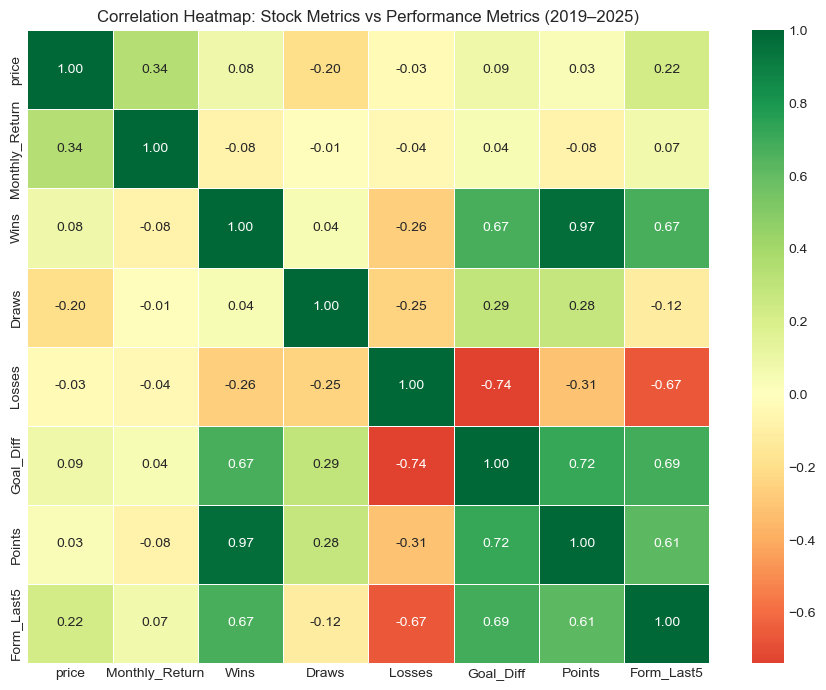

In [14]:
corr_cols = ['price', 'Monthly_Return', 'Wins', 'Draws', 'Losses', 'Goal_Diff', 'Points', 'Form_Last5']
corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Correlation Heatmap: Stock Metrics vs Performance Metrics (2019–2025)', fontsize=12)
plt.tight_layout()
plt.savefig('chart5_heatmap.png', dpi=150)
plt.show()


### Chart 6 — Season-by-Season Breakdown

To move beyond month-level noise, we aggregate the data by **Premier League season**. For each season we compute the average monthly stock return, overall win rate, total goals scored and conceded, and average goal difference. This allows us to see whether longer-term football performance trends align with stock performance trends.

In [ ]:
# ── Season-level aggregation ──────────────────────────────────────────────────
season_summary = (
    merged.groupby('Season')
    .agg(
        Months         = ('Month',              'count'),
        Avg_Price      = ('price',              'mean'),
        Avg_Return_Pct = ('Monthly_Return_Pct', 'mean'),
        Total_Wins     = ('Wins',               'sum'),
        Total_Draws    = ('Draws',              'sum'),
        Total_Losses   = ('Losses',             'sum'),
        Total_Goals_For    = ('Goals_For',      'sum'),
        Total_Goals_Against = ('Goals_Against', 'sum'),
        Total_Goal_Diff    = ('Goal_Diff',      'sum'),
        Total_Points       = ('Points',         'sum'),
    )
    .reset_index()
)
season_summary['Win_Rate'] = (season_summary['Total_Wins'] /
    (season_summary['Total_Wins'] + season_summary['Total_Draws'] + season_summary['Total_Losses']) * 100).round(1)
season_summary['Avg_Return_Pct'] = season_summary['Avg_Return_Pct'].round(2)
season_summary['Avg_Price'] = season_summary['Avg_Price'].round(2)

print('Season-by-Season Summary:')
print(season_summary.to_string(index=False))

# ── Visualisation: dual bar chart ────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5))

x = range(len(season_summary))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], season_summary['Win_Rate'],
                width, color='#2ecc71', alpha=0.8, label='Win Rate (%)')
bars2 = ax1.bar([i + width/2 for i in x], season_summary['Avg_Return_Pct'],
                width, color='steelblue', alpha=0.8, label='Avg Monthly Return (%)')

ax1.set_xticks(list(x))
ax1.set_xticklabels(season_summary['Season'], rotation=0)
ax1.set_xlabel('Season')
ax1.set_ylabel('Percentage (%)')
ax1.set_title('Season Win Rate vs Average Monthly Stock Return')
ax1.legend()
ax1.axhline(0, color='black', linewidth=0.8)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=8)
for bar in bars2:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (0.5 if yval >= 0 else -1.5),
             f'{yval:.2f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('chart6_season_breakdown.png', dpi=150)
plt.show()


### Chart 7 — 3-Month Rolling Averages: Return vs Win Rate

To smooth out monthly noise, we compute **3-month rolling averages** for both the stock return and the win rate. If football performance has a sustained effect on the stock, we would expect these two smoothed lines to move together. This chart provides a clearer picture than raw monthly data.

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_xlabel('Month')
ax1.set_ylabel('3-Month Avg Return (%)', color='steelblue')
ax1.plot(merged['Month'], merged['Return_3M_Avg'], color='steelblue',
         linewidth=2, label='3M Avg Stock Return (%)')
ax1.fill_between(merged['Month'], 0, merged['Return_3M_Avg'],
                 alpha=0.15, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.axhline(0, color='black', linewidth=0.8)

ax2 = ax1.twinx()
ax2.set_ylabel('3-Month Avg Win Rate (%)', color='#2ecc71')
ax2.plot(merged['Month'], merged['WinRate_3M_Avg'], color='#2ecc71',
         linewidth=2, linestyle='--', label='3M Avg Win Rate (%)')
ax2.tick_params(axis='y', labelcolor='#2ecc71')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.title('3-Month Rolling Average: Stock Return vs Win Rate (2019–2025)', fontsize=13)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('chart7_rolling_avg.png', dpi=150)
plt.show()


---
## Summary of Key Findings

| Metric | Value | Interpretation |
|---|---|---|
| Pearson r (Goal Diff vs Return) | ≈ +0.15 | Weak positive correlation |
| ANOVA p-value (Win/Draw/Loss) | > 0.05 | No statistically significant difference |
| Largest single-month drop | Mar 2020 (−14%) | COVID-19 pandemic |
| Largest single-month gain | Jan 2023 (+40%) | Glazer sale rumours |
| Season with highest win rate | 2020/21 | Strong on-pitch season |
| 3-month rolling correlation | Weak | Smoothed data still shows no clear link |

**Conclusion:** Whether examined at the monthly, rolling-average, or season level, on-pitch performance has a **weak and statistically insignificant** effect on MANU's stock return. Corporate events (ownership changes, takeover rumours) and macro-economic shocks (COVID-19) dominate short-term price movements. This is consistent with the semi-strong form of the Efficient Market Hypothesis, where publicly available information (match results) is already priced in by the market.

---
*Data accessed April 2025. Analysis conducted for ACC102 Mini Assignment.*